In [7]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [8]:
# Calculate daily returns for each mutual fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Display the first few rows
nav[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [9]:
# Summary statistics of daily returns
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

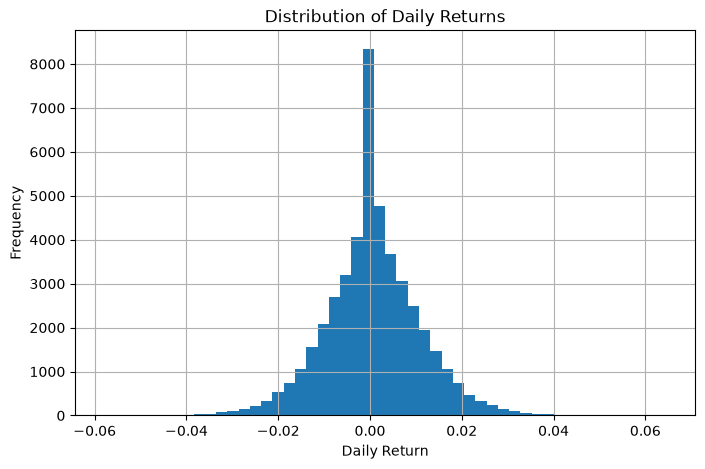

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
nav["daily_return"].dropna().hist(bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [11]:
import pandas as pd

# First and last NAV for each fund
cagr_df = nav.groupby("amfi_code").agg(
    start_nav=("nav", "first"),
    end_nav=("nav", "last"),
    start_date=("date", "first"),
    end_date=("date", "last")
).reset_index()

# Number of years
cagr_df["years"] = (
    (cagr_df["end_date"] - cagr_df["start_date"]).dt.days / 365.25
)

# CAGR Calculation
cagr_df["CAGR"] = (
    (cagr_df["end_nav"] / cagr_df["start_nav"]) ** (1 / cagr_df["years"]) - 1
)

# Convert to percentage
cagr_df["CAGR (%)"] = cagr_df["CAGR"] * 100

cagr_df[["amfi_code", "CAGR (%)"]].head()

,amfi_code,CAGR (%)
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [12]:
cagr_df = cagr_df.sort_values("CAGR (%)", ascending=False)

cagr_df[["amfi_code", "CAGR (%)"]].head(10)

,amfi_code,CAGR (%)
25,120505,32.827406
21,119598,32.423536
39,149324,32.287440
36,148569,31.949523
34,148567,30.974108
30,120843,30.907455
2,100033,30.123153
38,149323,29.581087
16,119094,28.214417
19,119551,25.804686


In [13]:
cagr_df.to_csv("../reports/fund_cagr.csv", index=False)

In [14]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [15]:
nav["amfi_code"].nunique()

40

In [16]:
import numpy as np

# Annual risk-free rate
risk_free_rate = 0.065

# Convert annual rate to daily rate
daily_rf = risk_free_rate / 252

# Calculate Sharpe Ratio for each fund
sharpe = nav.groupby("amfi_code")["daily_return"].apply(
    lambda x: ((x.mean() - daily_rf) / x.std()) * np.sqrt(252)
)

# Convert to DataFrame
sharpe_df = sharpe.reset_index()
sharpe_df.columns = ["amfi_code", "Sharpe_Ratio"]

# Rank funds
sharpe_df = sharpe_df.sort_values("Sharpe_Ratio", ascending=False)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [17]:
sharpe_df.to_csv("../reports/sharpe_ratio.csv", index=False)

In [18]:
import numpy as np

risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

def sortino_ratio(returns):
    returns = returns.dropna()

    # Downside returns only
    downside = returns[returns < 0]

    if len(downside) == 0:
        return np.nan

    downside_std = downside.std()

    if downside_std == 0:
        return np.nan

    return ((returns.mean() - daily_rf) / downside_std) * np.sqrt(252)

sortino_df = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(sortino_ratio)
       .reset_index()
)

sortino_df.columns = ["amfi_code", "Sortino_Ratio"]

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [19]:
sortino_df.to_csv("../reports/sortino_ratio.csv", index=False)

In [20]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.columns)
benchmark.head()

Index(['date', 'index_name', 'close_value'], dtype='str')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [ ]:
from scipy.stats import linregress

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

# Keep only NIFTY100 data
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

# Calculate benchmark daily returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta.append({
            "amfi_code": fund,
            "Alpha": intercept * 252,
            "Beta": slope
        })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

ModuleNotFoundError: No module named 'scipy'

In [22]:
from scipy.stats import linregress